<a href="https://colab.research.google.com/github/LavanyaMaruthachalam/Acoustic-Bowel-Movements/blob/main/Copy_of_Final_Version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Upload your files to Colab (zip or csv + wavs)

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from google.colab import files
import matplotlib.pyplot as plt
import librosa, librosa.display
import os, glob, zipfile
from IPython.display import Audio, display
import plotly.express as px


In [ ]:

uploaded = files.upload()  # choose your zip or csv/wavs
print("Uploaded:", list(uploaded.keys()))


Saving dataset_v2_filtered.zip to dataset_v2_filtered.zip
Uploaded: ['dataset_v2_filtered.zip']


In [ ]:
# Find the first uploaded zip
zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if zip_files:
    zip_path = zip_files[0]
    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data")
    print("Extracted to: data/")
else:
    print("No zip uploaded. If you uploaded csv/wavs directly, skip this step.")



# Search for the metadata file
candidates = glob.glob("**/dataset_metadata.csv", recursive=True)
print("Found metadata files:", candidates)

if not candidates:
    raise FileNotFoundError("dataset_metadata.csv not found. Upload it or unzip the correct folder.")

meta_path = candidates[0]
df_raw = pd.read_csv(meta_path)
print("Using:", meta_path)
print(len(df_raw))
df_raw.head(5)


Unzipping: dataset_v2_filtered.zip
Extracted to: data/
Found metadata files: ['data/dataset_metadata.csv']
Using: data/dataset_metadata.csv
7112


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


In [ ]:
# Remove outlier session 7

print("Rows before filter:", len(df_raw))
print("Sessions:", df_raw["session_id"].nunique())

OUTLIER_SESSION_ID = 7
df = df_raw[df_raw["session_id"] != OUTLIER_SESSION_ID].copy()

print("Rows after filter:", len(df))
print("Sessions:", df["session_id"].nunique())

Rows before filter: 7112
Sessions: 11
Rows after filter: 6348
Sessions: 10


🔥 STEP 1 — Precisely Detect Defecation Boundaries

In [ ]:
# --- Cycle-aware structure (NEW) ---
df = df.sort_values(["session_id", "datetime"]).copy()

# Detect cycle boundaries within each session
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()

# A new cycle starts when minutes_until_defecation jumps upward
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)

# Cycle id within session (0,1,2,...)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()

# Global unique cycle id (string)
df["global_cycle_id"] = (
    df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)
)

# Quick sanity checks
cycles_per_session = df.groupby("session_id")["cycle_id"].nunique()
print("Cycles per session:\n", cycles_per_session)

bad_cycles = df.groupby("global_cycle_id")["minutes_until_defecation"].apply(
    lambda s: (s.diff() > 0).sum()
)
print("Non-monotonic cycles (should be 0):", (bad_cycles > 0).sum())

Cycles per session:
 session_id
1     1
2     3
3     2
4     3
5     2
6     3
8     1
9     4
10    2
11    1
Name: cycle_id, dtype: int64
Non-monotonic cycles (should be 0): 0


Shape (events): (6348, 14)

Columns:
 ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file', 'minute_diff', 'new_cycle_flag', 'cycle_id', 'global_cycle_id']

Missing values (%):
 filename                          0.00
session_id                        0.00
datetime                          0.00
chunk_index                       0.00
minutes_until_defecation          0.50
minutes_since_last_defecation    13.04
minutes_since_meal                1.01
minutes_since_wake                0.00
duration                          0.00
original_file                     0.00
minute_diff                       0.66
new_cycle_flag                    0.00
cycle_id                          0.00
global_cycle_id                   0.00
dtype: float64

Unique sessions: 10
Unique defecation cycles (anchors): 22

Cycles per session:
 session_id
1     1
2     3
3     2
4     3
5 

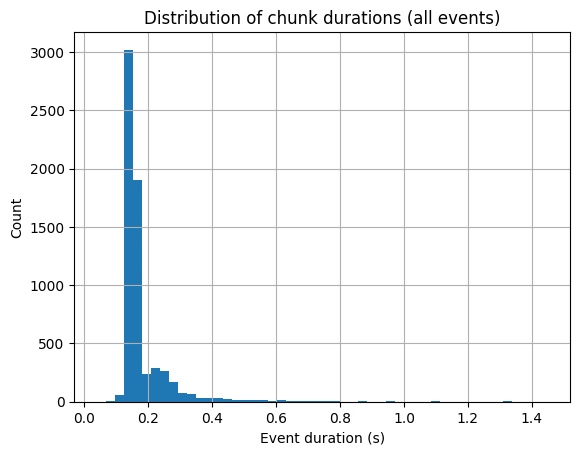

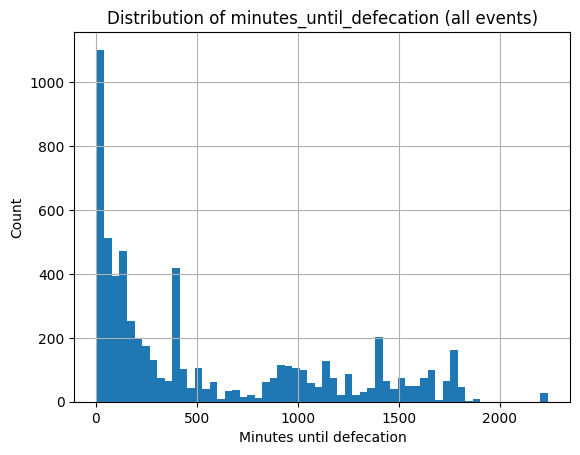

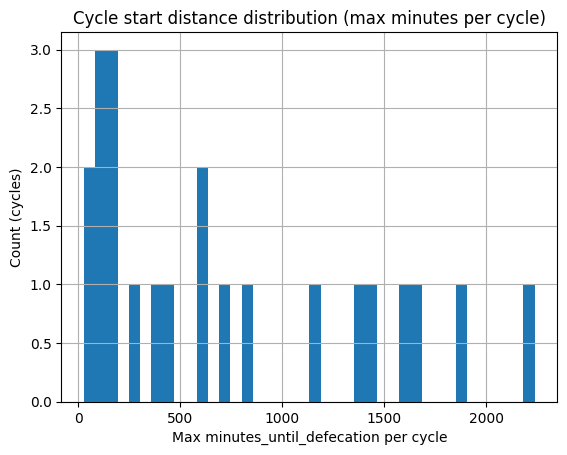

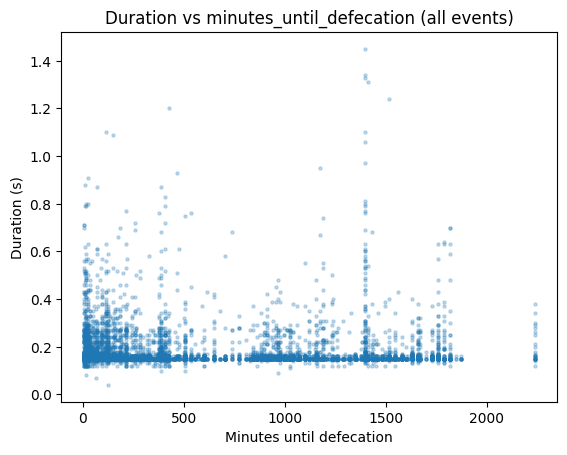

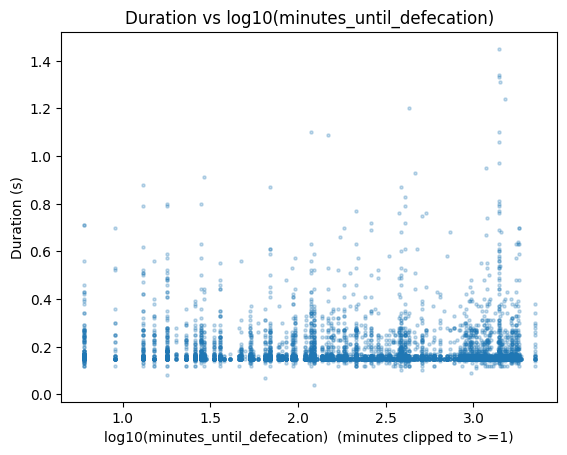

In [ ]:
# 4) Basic metadata inspection + quick plots (CYCLE-AWARE)
# Assumes df already has: session_id, datetime, minutes_until_defecation, duration

import numpy as np
import matplotlib.pyplot as plt

# --- Ensure sorted + build cycles if not already present ---
df = df.sort_values(["session_id", "datetime"]).copy()

if "global_cycle_id" not in df.columns:
    df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
    df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
    df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
    df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

# --- Basic inspection ---
print("Shape (events):", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (%):\n", (df.isna().mean() * 100).round(2))

n_sessions = df["session_id"].nunique()
n_cycles = df["global_cycle_id"].nunique()
print(f"\nUnique sessions: {n_sessions}")
print(f"Unique defecation cycles (anchors): {n_cycles}")

# How many cycles per session?
cycles_per_session = df.groupby("session_id")["global_cycle_id"].nunique().sort_index()
print("\nCycles per session:\n", cycles_per_session)

# Events per cycle (to see if a few cycles dominate)
events_per_cycle = df.groupby("global_cycle_id").size().sort_values(ascending=False)
print("\nTop 10 cycles by #events:\n", events_per_cycle.head(10))

# --- Duration distribution ---
plt.figure()
df["duration"].dropna().hist(bins=50)
plt.xlabel("Event duration (s)")
plt.ylabel("Count")
plt.title("Distribution of chunk durations (all events)")
plt.show()

# --- minutes_until_defecation distribution ---
plt.figure()
df["minutes_until_defecation"].dropna().hist(bins=60)
plt.xlabel("Minutes until defecation")
plt.ylabel("Count")
plt.title("Distribution of minutes_until_defecation (all events)")
plt.show()

# --- NEW: per-cycle max minutes distribution (sanity: where cycles start) ---
cycle_max = df.groupby("global_cycle_id")["minutes_until_defecation"].max().dropna()
plt.figure()
cycle_max.hist(bins=40)
plt.xlabel("Max minutes_until_defecation per cycle")
plt.ylabel("Count (cycles)")
plt.title("Cycle start distance distribution (max minutes per cycle)")
plt.show()

# --- Duration vs minutes_until_defecation scatter (cycle-aware) ---
tmp = df.dropna(subset=["minutes_until_defecation", "duration"]).copy()

plt.figure()
plt.scatter(tmp["minutes_until_defecation"], tmp["duration"], s=5, alpha=0.25)
plt.xlabel("Minutes until defecation")
plt.ylabel("Duration (s)")
plt.title("Duration vs minutes_until_defecation (all events)")
plt.show()

# --- Optional: log-x view (often reveals structure better) ---
plt.figure()
x = tmp["minutes_until_defecation"].clip(lower=1)  # avoid log(0)
plt.scatter(np.log10(x), tmp["duration"], s=5, alpha=0.25)
plt.xlabel("log10(minutes_until_defecation)  (minutes clipped to >=1)")
plt.ylabel("Duration (s)")
plt.title("Duration vs log10(minutes_until_defecation)")
plt.show()

In [ ]:
df_raw = df.copy()  # keep original

# rows where minutes_until_defecation is NaN
t2d_nan = df_raw[df_raw["minutes_until_defecation"].isna()].copy()
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(50))

print(t2d_nan["session_id"].value_counts(dropna=False))

# now drop
df = df_raw.dropna(subset=["minutes_until_defecation"]).copy()
print("After drop, df rows:", len(df))

Rows with minutes_until_defecation NaN: 32


,filename,session_id,datetime,minutes_until_defecation
7080,11_22_2312_chunk_001.wav,11,2025-11-22 23:12:00,NaN
7081,11_22_2312_chunk_002.wav,11,2025-11-22 23:12:00,NaN
7082,11_22_2312_chunk_003.wav,11,2025-11-22 23:12:00,NaN
7083,11_22_2312_chunk_004.wav,11,2025-11-22 23:12:00,NaN
7084,11_22_2312_chunk_005.wav,11,2025-11-22 23:12:00,NaN
7085,11_22_2312_chunk_006.wav,11,2025-11-22 23:12:00,NaN
7086,11_22_2312_chunk_007.wav,11,2025-11-22 23:12:00,NaN
7087,11_22_2312_chunk_008.wav,11,2025-11-22 23:12:00,NaN
7088,11_22_2312_chunk_009.wav,11,2025-11-22 23:12:00,NaN
7089,11_22_2345_chunk_001.wav,11,2025-11-22 23:45:00,NaN


session_id
11    32
Name: count, dtype: int64
After drop, df rows: 6316


In [ ]:
nan_summary = df_raw.isna().sum()
print(nan_summary[nan_summary > 0].sort_values(ascending=False))

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       42
minutes_until_defecation          32
dtype: int64


In [ ]:
nan_summary = df.isna().sum()
print(nan_summary[nan_summary > 0])

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       10
dtype: int64


Specifically inspect minutes_until_defecation NaNs

In [ ]:
t2d_nan = df[df["minutes_until_defecation"].isna()]
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(20))

Rows with minutes_until_defecation NaN: 0


,filename,session_id,datetime,minutes_until_defecation


In [ ]:
df[df["minutes_until_defecation"].isna()]["session_id"].value_counts()

,count
session_id,


See which columns cause NaNs

Found chunks folders: ['data/chunks']
Using chunks dir: data/chunks

Chosen cycles (closest-first): ['2_0', '3_0', '6_0']

Samples per chosen cycle:
                 count  min  max
global_cycle_id                 
2_0                  3  6.0  6.0
3_0                  3  6.0  6.0
6_0                  3  6.0  6.0

Cycle: 2_0 | File: 10_29_1614_chunk_001.wav | sr=8000 | dur=0.17s | t2d=6.0 min


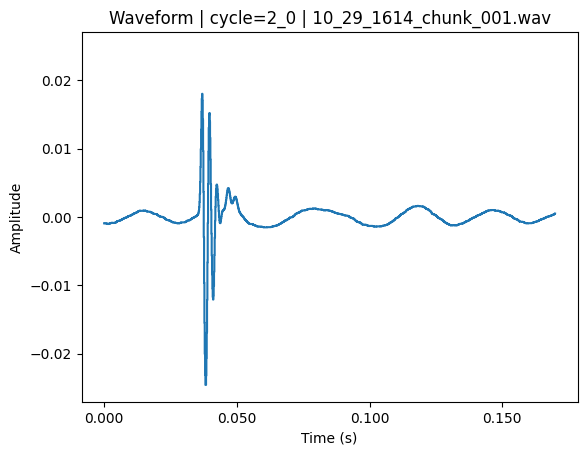

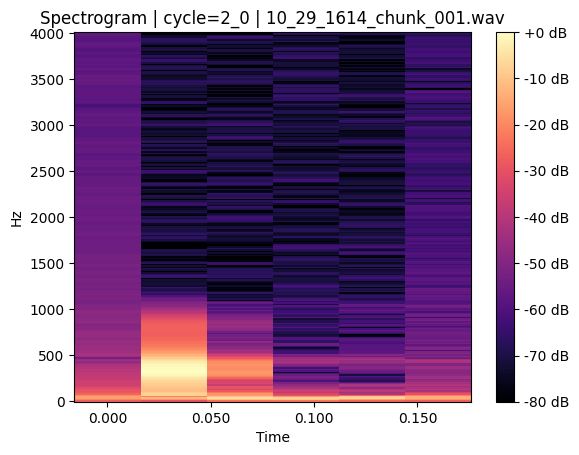


Cycle: 2_0 | File: 10_29_1614_chunk_002.wav | sr=8000 | dur=0.16s | t2d=6.0 min


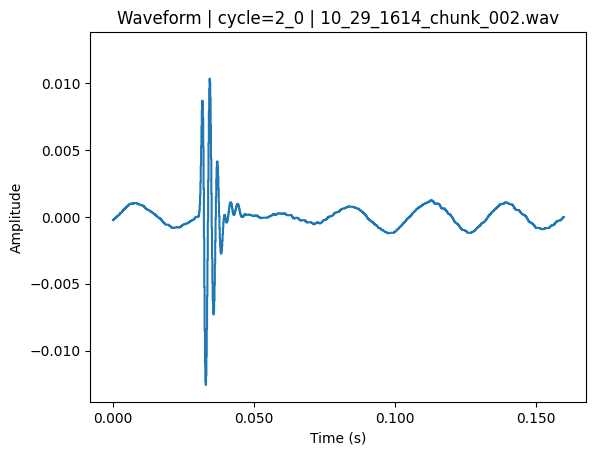

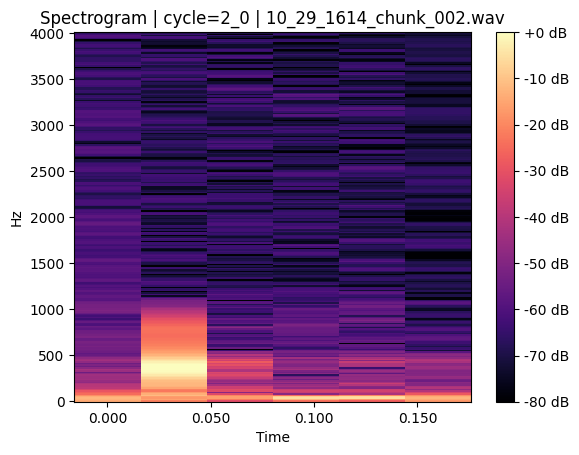


Cycle: 2_0 | File: 10_29_1614_chunk_003.wav | sr=8000 | dur=0.16s | t2d=6.0 min


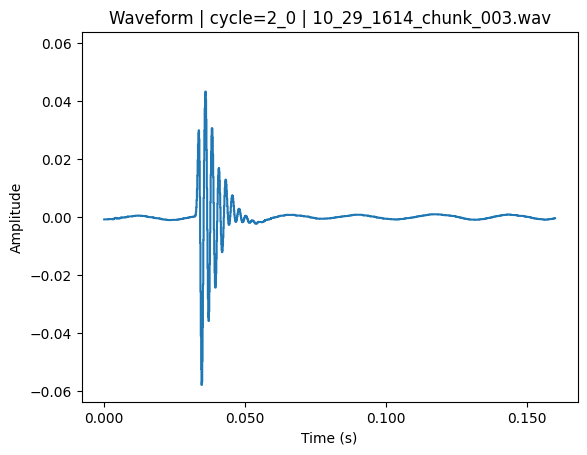

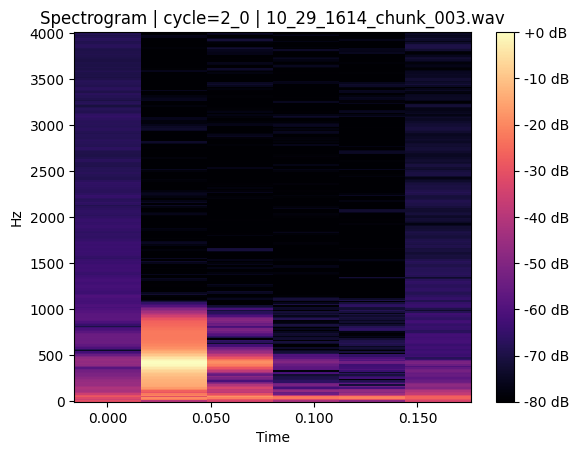


Cycle: 3_0 | File: 10_30_1824_chunk_001.wav | sr=8000 | dur=0.17s | t2d=6.0 min


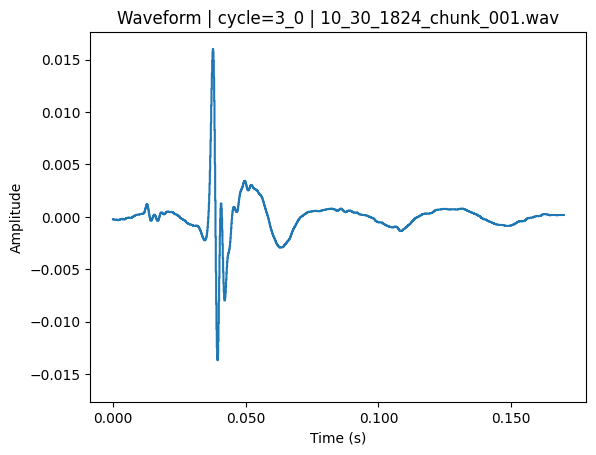

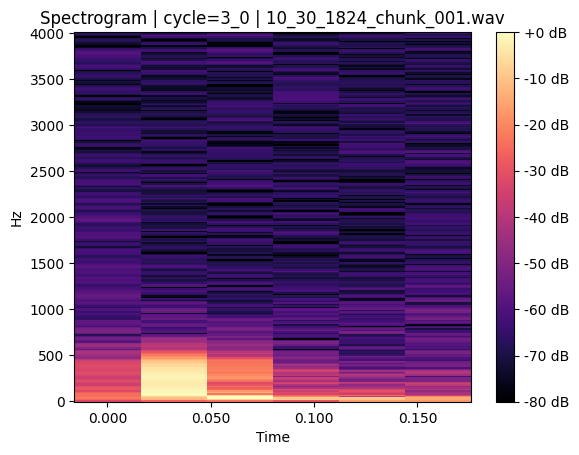


Cycle: 3_0 | File: 10_30_1824_chunk_002.wav | sr=8000 | dur=0.17s | t2d=6.0 min


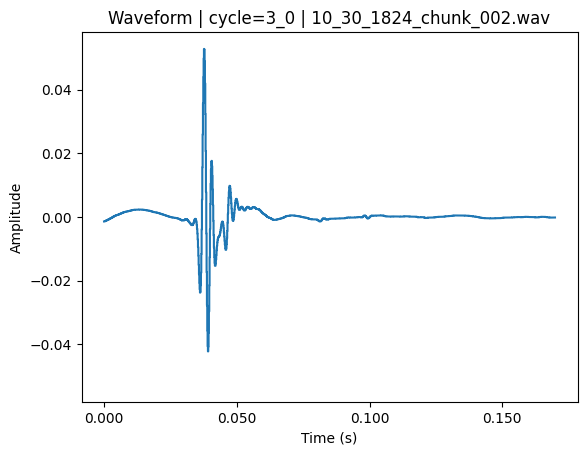

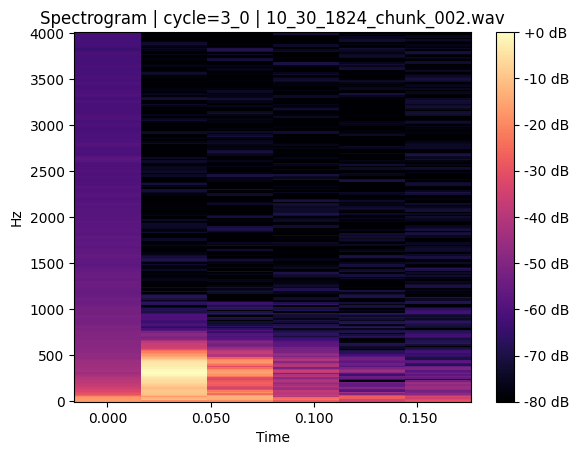


Cycle: 3_0 | File: 10_30_1824_chunk_003.wav | sr=8000 | dur=0.26s | t2d=6.0 min


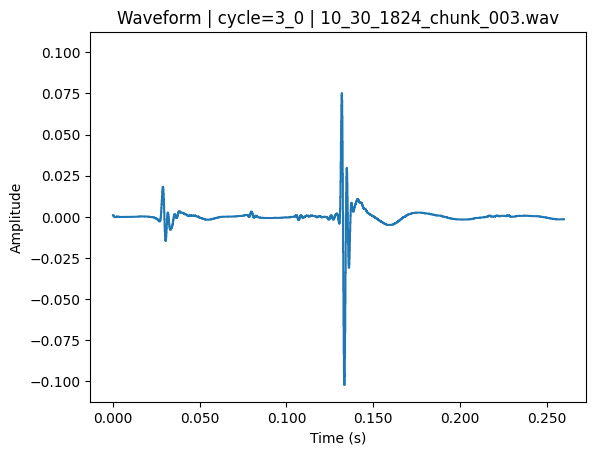

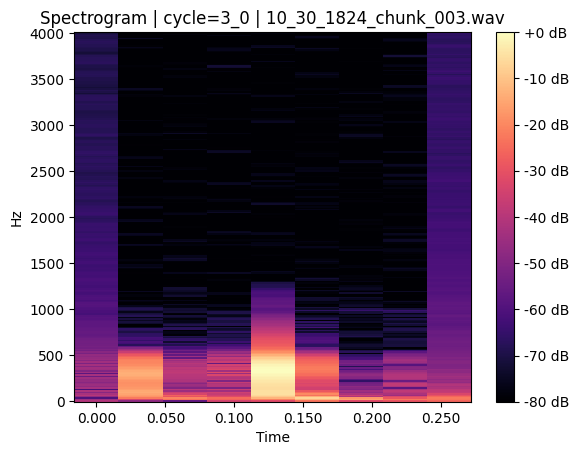


Cycle: 6_0 | File: 11_3_1746_chunk_001.wav | sr=8000 | dur=0.15s | t2d=6.0 min


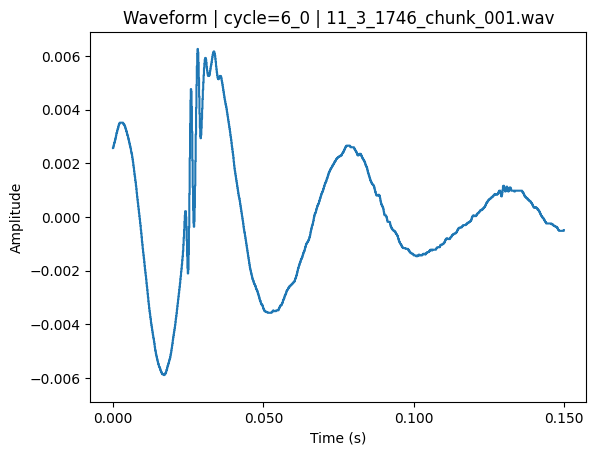

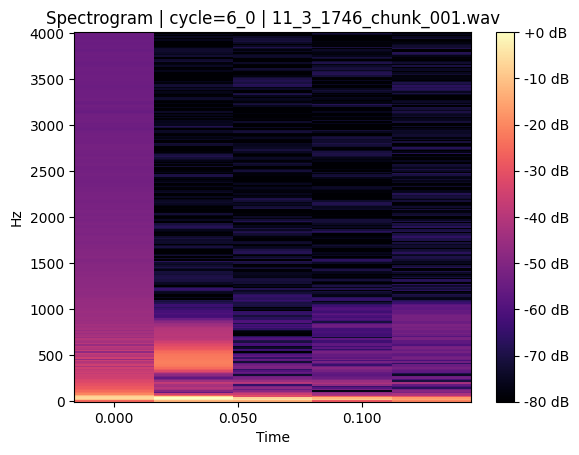


Cycle: 6_0 | File: 11_3_1746_chunk_002.wav | sr=8000 | dur=0.15s | t2d=6.0 min


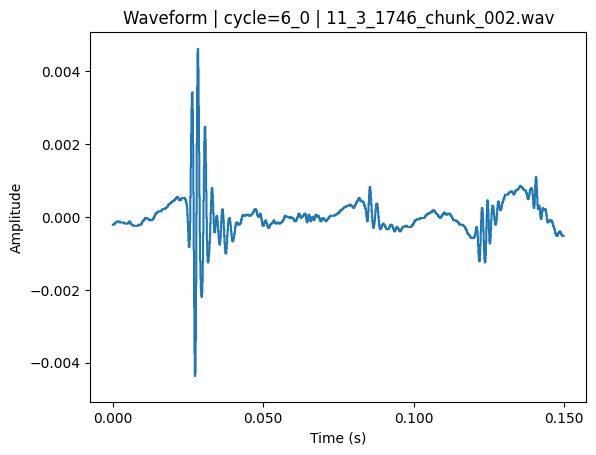

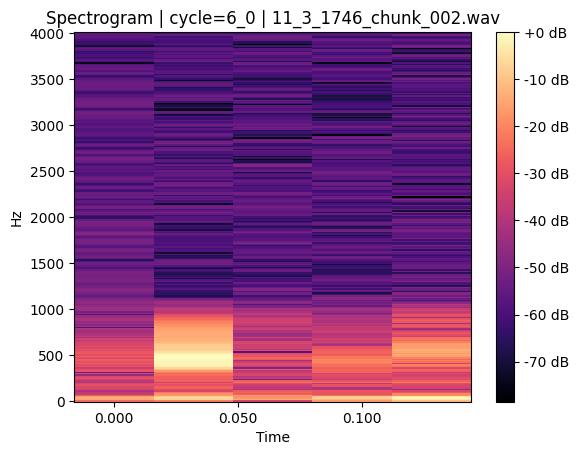


Cycle: 6_0 | File: 11_3_1746_chunk_003.wav | sr=8000 | dur=0.15s | t2d=6.0 min


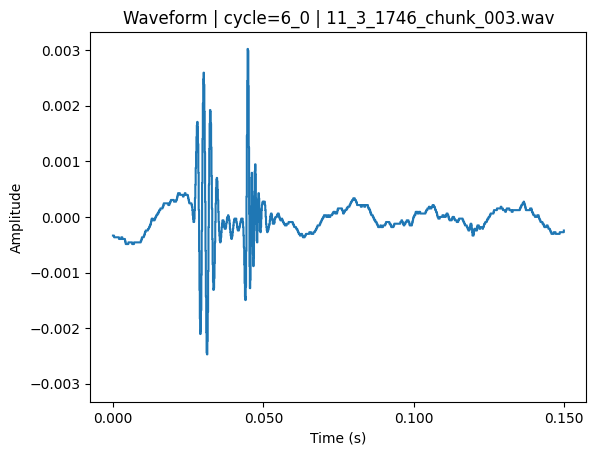

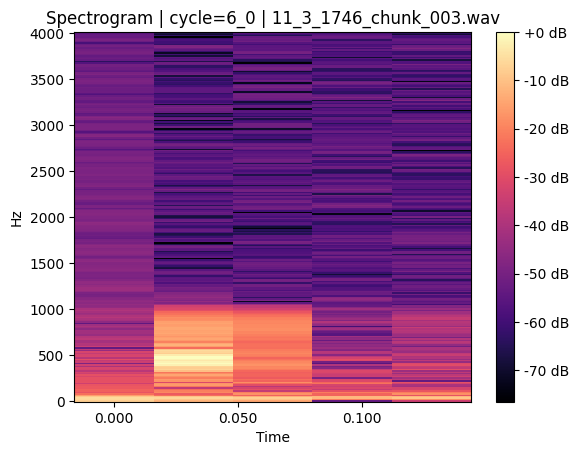

In [ ]:
# 6) Load and visualize WAV chunks (CYCLE-AWARE)
# - Finds chunks/ folder
# - Picks a few cycles and within each cycle picks chunks nearest to defecation
# - Plots waveform + spectrogram + playback

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from IPython.display import Audio, display

# ---------- Ensure cycle columns exist ----------
df = df.sort_values(["session_id", "datetime"]).copy()

if "global_cycle_id" not in df.columns:
    df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
    df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
    df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
    df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

# ---------- Find chunks folder ----------
chunks_dirs = [p for p in glob.glob("**/chunks", recursive=True) if os.path.isdir(p)]
print("Found chunks folders:", chunks_dirs)

if not chunks_dirs:
    print("No chunks/ folder found. Upload wav files or unzip dataset folder containing chunks/")
else:
    chunks_dir = chunks_dirs[0]
    print("Using chunks dir:", chunks_dir)

    # ---------- Choose samples cycle-aware ----------
    has_t2d = ("minutes_until_defecation" in df.columns) and df["minutes_until_defecation"].notna().any()
    if not has_t2d:
        # Fallback: random files if target missing
        sample_df = df.sample(10, random_state=42)
        chosen = sample_df
        print("\nminutes_until_defecation not available -> using random samples.")
    else:
        # Choose cycles first, then take nearest-to-defecation K samples per cycle
        N_CYCLES = 3          # how many cycles to inspect
        K_PER_CYCLE = 3       # how many nearest samples per cycle
        MAX_MINUTES = 60      # focus window near defecation (set None to disable)

        working = df.dropna(subset=["minutes_until_defecation", "filename", "global_cycle_id"]).copy()

        if MAX_MINUTES is not None:
            working = working[working["minutes_until_defecation"] <= MAX_MINUTES]

        # If too few near-defecation rows, relax window automatically
        if working.empty:
            print(f"\nNo events found within <= {MAX_MINUTES} minutes. Relaxing filter to use global nearest samples.")
            working = df.dropna(subset=["minutes_until_defecation", "filename", "global_cycle_id"]).copy()

        # pick cycles that actually have data
        cycle_order = (
            working.groupby("global_cycle_id")["minutes_until_defecation"]
                   .min()
                   .sort_values()
                   .index.tolist()
        )
        chosen_cycles = cycle_order[:N_CYCLES]

        chosen = (
            working[working["global_cycle_id"].isin(chosen_cycles)]
            .sort_values(["global_cycle_id", "minutes_until_defecation"])
            .groupby("global_cycle_id", group_keys=False)
            .head(K_PER_CYCLE)
        )

        print("\nChosen cycles (closest-first):", chosen_cycles)
        print("\nSamples per chosen cycle:")
        print(chosen.groupby("global_cycle_id")["minutes_until_defecation"].agg(["count", "min", "max"]))

    # ---------- Visualize ----------
    for idx, row in chosen.iterrows():
        wav_path = os.path.join(chunks_dir, row["filename"])
        if not os.path.exists(wav_path):
            print("Missing wav:", wav_path)
            continue

        y, sr = librosa.load(wav_path, sr=None, mono=True)

        print(
            f"\nCycle: {row.get('global_cycle_id', 'NA')} | "
            f"File: {row['filename']} | sr={sr} | dur={len(y)/sr:.2f}s | "
            f"t2d={row.get('minutes_until_defecation', None)} min"
        )

        # Waveform
        plt.figure()
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform | cycle={row.get('global_cycle_id', 'NA')} | {row['filename']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # Spectrogram (dB)
        n_fft = 512
        hop = 256
        S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        plt.figure()
        librosa.display.specshow(S_db, sr=sr, hop_length=hop, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram | cycle={row.get('global_cycle_id', 'NA')} | {row['filename']}")
        plt.show()

        # Playback
        display(Audio(y, rate=sr))

In [ ]:
import os
import pandas as pd

# ---------------------------
# Step 0: Dataset paths (robust)
# ---------------------------
# Option A: If you know the folder name, keep it:
DATASET_ROOT = "data"

# Option B (recommended): auto-detect dataset root containing dataset_metadata.csv
if not os.path.exists(os.path.join(DATASET_ROOT, "dataset_metadata.csv")):
    candidates = []
    for root, dirs, files in os.walk("."):
        if "dataset_metadata.csv" in files:
            candidates.append(root)
    if candidates:
        # choose the shortest path (usually the top-most dataset folder)
        DATASET_ROOT = sorted(candidates, key=len)[0]

META_PATH  = os.path.join(DATASET_ROOT, "dataset_metadata.csv")
CHUNKS_DIR = os.path.join(DATASET_ROOT, "chunks")

print("Using DATASET_ROOT:", DATASET_ROOT)
print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))


# ---------------------------
# Step 2: Keep events with valid minutes_until_defecation (CYCLE-AWARE)
# ---------------------------

df2 = df.copy()

# Ensure datetime is parsed for correct ordering
df2["datetime"] = pd.to_datetime(df2["datetime"], errors="coerce")

# Keep rows with valid target
df2 = df2[df2["minutes_until_defecation"].notna()].copy()
df2["minutes_until_defecation"] = df2["minutes_until_defecation"].astype(float)

# Sort before cycle detection
df2 = df2.sort_values(["session_id", "datetime"]).copy()

# ---- Build cycles (defecation-anchor segments) ----
df2["minute_diff"] = df2.groupby("session_id")["minutes_until_defecation"].diff()
df2["new_cycle_flag"] = (df2["minute_diff"] > 0).astype(int)
df2["cycle_id"] = df2.groupby("session_id")["new_cycle_flag"].cumsum()
df2["global_cycle_id"] = df2["session_id"].astype(str) + "_" + df2["cycle_id"].astype(str)

print("\nEvents with target:", len(df2))
print("Target range (min):", df2["minutes_until_defecation"].min(), "to", df2["minutes_until_defecation"].max())

print("\nUnique sessions:", df2["session_id"].nunique())
print("Unique cycles (defecation anchors):", df2["global_cycle_id"].nunique())

print("\nCycles per session:")
print(df2.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# Quick peek
cols = ["filename", "session_id", "global_cycle_id", "datetime", "minutes_until_defecation", "duration"]
print("\nPreview:")
display(df2[cols].head())

Using DATASET_ROOT: data
META exists: True
CHUNKS dir exists: True

Events with target: 6316
Target range (min): 6.0 to 2238.0

Unique sessions: 10
Unique cycles (defecation anchors): 22

Cycles per session:
session_id
1     1
2     3
3     2
4     3
5     2
6     3
8     1
9     4
10    2
11    1
Name: global_cycle_id, dtype: int64

Preview:


,filename,session_id,global_cycle_id,datetime,minutes_until_defecation,duration
0,10_28_1629_chunk_001.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.15
1,10_28_1629_chunk_002.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.20
2,10_28_1629_chunk_003.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.15
3,10_28_1629_chunk_004.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.17
4,10_28_1629_chunk_005.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.16


# UPDATED CODE SET 4 (Cycle-aware)

In [ ]:
# ============================================================
# CODE SET 4 (Merged) - UPDATED to CYCLE-AWARE
# ============================================================

# -------------------------
# 1) Paths + Output
OUT_DIR = "results_code_set4"
os.makedirs(OUT_DIR, exist_ok=True)

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))

# -------------------------
# 2) Global Parameters
# -------------------------
OUTLIER_SESSION_ID = 7
DROP_OUTLIER_SESSION = True

SESSIONS_TO_REMOVE = [1, 8, 9]

HP_CUTOFF_HZ = 20
HP_ORDER = 2

STFT_WINDOW = "hann"
STFT_BASE_NFFT_16K = 1024
STFT_BASE_NFFT_8K = 512
MIN_SPECTRAL_NPERSEG = 32

bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels_near_to_far = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]
order_far_to_near = [">24h","12-24h","8-12h","6-8h","4-6h","2-4h","1-2h","30-60m","0-30m"]

BASELINE_MIN = 480
MIN_BASELINE_N = 10

NEAR_MAX = 60
FAR_MIN = 480

Z_FEATURES = ["feat_centroid_mean", "feat_flatness_mean", "feat_duration_s", "feat_env_mean", "feat_zcr"]

# -------------------------
# 3) Utility Functions
# -------------------------
def teager_kaiser_energy(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.array([0.0])
    return x[1:-1]**2 - x[:-2] * x[2:]

def highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER):
    if len(x) < 64 or sr < 100:
        return x
    b, a = signal.butter(order, cutoff_hz / (sr / 2), btype="highpass")
    return signal.filtfilt(b, a, x)

def add_bins(df_):
    df_ = df_.copy()
    df_["t2d_bin"] = pd.cut(
        df_["minutes_until_defecation"],
        bins=bins,
        labels=labels_near_to_far,
        include_lowest=True
    )
    df_["t2d_bin"] = pd.Categorical(df_["t2d_bin"],
                                    categories=order_far_to_near,
                                    ordered=True)
    return df_

def rank_biserial_from_U(U, n1, n2):
    return 1 - (2 * U) / (n1 * n2)

def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0
    lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return (gt - lt) / (len(a) * len(b))

def bootstrap_ci_median(x, n_boot=800, ci=95, seed=42):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    meds = []
    for _ in range(n_boot):
        samp = rng.choice(x, size=len(x), replace=True)
        meds.append(np.median(samp))
    lo = np.percentile(meds, (100-ci)/2)
    hi = np.percentile(meds, 100-(100-ci)/2)
    return np.median(x), lo, hi

def _rolloff95(f, M):
    cumsum = np.cumsum(M, axis=0)
    total = cumsum[-1, :] + 1e-12
    T = cumsum.shape[1]
    roll = np.zeros(T, dtype=np.float32)
    for i in range(T):
        idx = np.searchsorted(cumsum[:, i], 0.95 * total[i])
        idx = min(idx, len(f) - 1)
        roll[i] = f[idx]
    return roll

# -------------------------
# 4) Hybrid Feature Extraction
# -------------------------
def extract_features_hybrid(wav_path):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    x = highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER)

    dur = len(x) / sr
    rms = float(np.sqrt(np.mean(x**2) + 1e-12))
    peak = float(np.max(np.abs(x)) + 1e-12)
    zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
    peak_to_rms = float(peak / (rms + 1e-12))

    env = np.abs(signal.hilbert(x)) + 1e-12
    env_mean = float(np.mean(env))
    env_std = float(np.std(env))
    env_max = float(np.max(env))
    env_crest = float(env_max / (env_mean + 1e-12))

    base_n_fft = STFT_BASE_NFFT_16K if sr >= 16000 else STFT_BASE_NFFT_8K
    nperseg = min(base_n_fft, len(x))

    if nperseg < MIN_SPECTRAL_NPERSEG:
        centroid = np.array([0.0])
        flatness = np.array([0.0])
        roll95_amp = np.array([0.0])
        roll95_pow = np.array([0.0])
        flux_mean = 0.0
    else:
        hop = max(1, nperseg // 4)
        noverlap = min(nperseg - 1, nperseg - hop)

        f, t, Z = signal.stft(
            x,
            fs=sr,
            nperseg=nperseg,
            noverlap=noverlap,
            window=STFT_WINDOW,
            padded=False,
            boundary=None
        )
        mag = np.abs(Z) + 1e-12
        pow_ = mag**2

        centroid = (f[:, None] * mag).sum(axis=0) / mag.sum(axis=0)
        flatness = np.exp(np.mean(np.log(mag), axis=0)) / (np.mean(mag, axis=0) + 1e-12)

        roll95_amp = _rolloff95(f, mag)
        roll95_pow = _rolloff95(f, pow_)

        flux = np.sqrt(np.sum(np.diff(mag, axis=1)**2, axis=0))
        flux_mean = float(np.mean(flux)) if flux.size else 0.0

    tkeo = np.abs(teager_kaiser_energy(x))
    tkeo_mean = float(np.mean(tkeo)) if tkeo.size else 0.0
    tkeo_max = float(np.max(tkeo)) if tkeo.size else 0.0

    return {
        "sr": int(sr),
        "feat_duration_s": float(dur),
        "feat_rms": rms,
        "feat_log_rms": float(np.log(rms + 1e-12)),
        "feat_peak_to_rms": peak_to_rms,
        "feat_zcr": zcr,
        "feat_env_mean": env_mean,
        "feat_env_std": env_std,
        "feat_env_crest": env_crest,
        "feat_centroid_mean": float(np.mean(centroid)),
        "feat_centroid_std": float(np.std(centroid)),
        "feat_flatness_mean": float(np.mean(flatness)),
        "feat_roll95_amp_mean": float(np.mean(roll95_amp)),
        "feat_roll95_pow_mean": float(np.mean(roll95_pow)),
        "feat_flux_mean": flux_mean,
        "feat_tkeo_mean": tkeo_mean,
        "feat_tkeo_max": tkeo_max,
        "stft_nperseg": int(nperseg),
        "stft_hop": int(max(1, nperseg // 4)) if nperseg >= MIN_SPECTRAL_NPERSEG else 0,
        "stft_window": STFT_WINDOW,
        "hp_cutoff_hz": HP_CUTOFF_HZ,
        "hp_order": HP_ORDER,
    }

# -------------------------
# 5) Load metadata safely + Filtering
# -------------------------
df_raw = pd.read_csv(META_PATH)
print("Rows raw:", len(df_raw), "Sessions raw:", df_raw["session_id"].nunique())

df = df_raw.copy()

# Parse datetime EARLY (important for correct cycle detection)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Remove outlier session 7
if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    df = df[df["session_id"] != OUTLIER_SESSION_ID].copy()
    print("Removed session:", OUTLIER_SESSION_ID)

if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    assert OUTLIER_SESSION_ID not in df["session_id"].unique(), "Session 7 leaked back into df!"

print("Rows after removing 7:", len(df), "Sessions:", df["session_id"].nunique())

# Remove sessions 1, 8, 9 and store separately
df_removed_1_8_9 = df[df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()
df_clean = df[~df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()

print("\nRemoved sessions stored separately:", sorted(df_removed_1_8_9["session_id"].unique()))
print("Rows in removed set:", len(df_removed_1_8_9))

print("\nRows after removing 1,8,9:", len(df_clean))
print("Sessions after:", sorted(df_clean["session_id"].unique()))

df = df_clean

# Keep valid target
df = df.dropna(subset=["minutes_until_defecation"]).copy()
df["minutes_until_defecation"] = df["minutes_until_defecation"].astype(float)

# Sort (required for cycle boundaries)
df = df.sort_values(["session_id", "datetime"]).copy()
print("\nRows with valid minutes_until_defecation:", len(df))

# -------------------------
# 5.5) NEW: Build defecation cycles inside sessions
# -------------------------
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

print("\nUnique sessions:", df["session_id"].nunique())
print("Unique defecation cycles (anchors):", df["global_cycle_id"].nunique())
print("\nCycles per session:\n", df.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# -------------------------
# 6) Extract features for ALL events (global dataset)
# -------------------------
feature_rows = []
missing = 0

for _, row in df.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, row["filename"])
    if not os.path.exists(wav_path):
        missing += 1
        continue
    feats = extract_features_hybrid(wav_path)
    feats["filename"] = row["filename"]
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Extracted feature rows:", len(feat_df), "Missing wavs:", missing)

data = df.merge(feat_df, on="filename", how="inner")
print("Merged rows:", len(data))

global_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4.csv")
data.to_csv(global_csv, index=False)
print("Saved global features:", global_csv)

# -------------------------
# 7) Global Binning (far -> near)
# -------------------------
data = add_bins(data)
bin_counts = data["t2d_bin"].value_counts().sort_index()
print("\nBin counts (far -> near):")
print(bin_counts)

# -------------------------
# 8) CYCLE-NORMALIZATION (z-scores)  <<<<< CHANGED HERE
# -------------------------
data_norm = data.copy()
for f in Z_FEATURES:
    data_norm[f + "_z"] = np.nan
data_norm["baseline_n"] = 0

def cycle_zscore(df_cycle):
    df_cycle = df_cycle.copy()
    base = df_cycle[df_cycle["minutes_until_defecation"] >= BASELINE_MIN]
    df_cycle["baseline_n"] = len(base)

    if len(base) < MIN_BASELINE_N:
        return df_cycle

    mu = base[Z_FEATURES].mean()
    sd = base[Z_FEATURES].std(ddof=0).replace(0, np.nan)

    for f in Z_FEATURES:
        df_cycle[f + "_z"] = (df_cycle[f] - mu[f]) / sd[f]
    return df_cycle

# IMPORTANT: group by global_cycle_id now
data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)
data_norm = add_bins(data_norm)

norm_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4_norm.csv")
data_norm.to_csv(norm_csv, index=False)
print("Saved normalized features:", norm_csv)

# -------------------------
# 9) Global Stats Table (same global, but now data has cycles)
# -------------------------
feature_cols = [c for c in data.columns if c.startswith("feat_") and not c.endswith("_z")]

tmp = data.dropna(subset=["minutes_until_defecation"]).copy()
near_df = tmp[tmp["minutes_until_defecation"] <= NEAR_MAX]
far_df  = tmp[tmp["minutes_until_defecation"] >= FAR_MIN]
print("\nNear N:", len(near_df), "Far N:", len(far_df))

rows = []
for feat in feature_cols:
    t = tmp.dropna(subset=[feat, "minutes_until_defecation"])
    if len(t) < 20:
        rho, p_s = np.nan, np.nan
    else:
        rho, p_s = stats.spearmanr(t[feat].values, t["minutes_until_defecation"].values)

    a = near_df[feat].dropna().values
    b = far_df[feat].dropna().values
    if len(a) < 30 or len(b) < 30:
        mw_p = np.nan
        rbc = np.nan
        cd = np.nan
    else:
        U, mw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rbc = rank_biserial_from_U(U, len(a), len(b))
        cd = cliffs_delta(a, b)

    rows.append({
        "feature": feat,
        "spearman_rho": rho,
        "spearman_p": p_s,
        "mw_p": mw_p,
        "rank_biserial": rbc,
        "cliffs_delta": cd,
        "near_N": len(a),
        "far_N": len(b),
    })

stats_df = pd.DataFrame(rows).sort_values("mw_p")
stats_csv = os.path.join(OUT_DIR, "global_stats_codeset4.csv")
stats_df.to_csv(stats_csv, index=False)
print("\nSaved global stats:", stats_csv)

# -------------------------
# 10) Global Plots (Raw medians)
# -------------------------
top_feats = stats_df.sort_values("spearman_p").head(6)["feature"].tolist()

for c in top_feats:
    grp = data.groupby("t2d_bin", observed=True)[c].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(f"Global median: {c} (far -> near)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(c)
    plt.xticks(rotation=45)
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_raw_{c}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

# -------------------------
# 11) Global Plots (Z-score medians + bootstrap CI) [now cycle-normalized]
# -------------------------
important_feats_z = ["feat_centroid_mean_z", "feat_flatness_mean_z", "feat_duration_s_z"]

for fz in important_feats_z:
    rows_ci = []
    for b in order_far_to_near:
        vals = data_norm.loc[data_norm["t2d_bin"] == b, fz].values
        med, lo, hi = bootstrap_ci_median(vals, n_boot=800, ci=95, seed=42)
        rows_ci.append((b, med, lo, hi, np.sum(~np.isnan(vals))))
    plot_df = pd.DataFrame(rows_ci, columns=["bin","median","ci_low","ci_high","N"])

    plt.figure()
    plt.errorbar(
        plot_df["bin"],
        plot_df["median"],
        yerr=[plot_df["median"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["median"]],
        fmt="o-"
    )
    plt.axhline(0, linestyle="--", color="gray", label="Baseline (z=0)")
    plt.title(f"Global cycle-normalized {fz} (median ± 95% bootstrap CI)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel("z-score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_z_{fz}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

    ci_csv = os.path.join(OUT_DIR, f"global_ci_{fz}.csv")
    plot_df.to_csv(ci_csv, index=False)

# -------------------------
# 12) Per-CYCLE outputs + Cycle Summary  <<<<< CHANGED HERE
# -------------------------
CYCLE_SUMMARY = []
all_cycles = sorted(data["global_cycle_id"].unique())

def plot_trend(df_, col, title, outpng):
    grp = df_.groupby("t2d_bin", observed=True)[col].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(title)
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(outpng, dpi=150)
    plt.close()

for cid in all_cycles:
    cyc_dir = os.path.join(OUT_DIR, f"cycle_{cid}")
    os.makedirs(cyc_dir, exist_ok=True)

    df_cyc = data[data["global_cycle_id"] == cid].copy()
    df_cyc = add_bins(df_cyc)

    # apply cycle zscore
    df_cyc_norm = cycle_zscore(df_cyc)

    csv_path = os.path.join(cyc_dir, f"features_cycle_{cid}.csv")
    df_cyc_norm.to_csv(csv_path, index=False)

    # Raw plots
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"raw_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} raw median: {col}", outpng)

    # Z plots
    for col in [f + "_z" for f in Z_FEATURES]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"z_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} z-score median: {col}", outpng)

    # Spearman within cycle
    scores = {}
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col not in df_cyc_norm.columns:
          continue
        tmp_c = df_cyc_norm.dropna(subset=[col, "minutes_until_defecation"])
        if len(tmp_c) < 20:
            rho, p = np.nan, np.nan
        else:
            rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
        scores[col + "_rho"] = rho
        scores[col + "_p"] = p

    baseline_n = int(df_cyc_norm["baseline_n"].iloc[0]) if "baseline_n" in df_cyc_norm.columns else 0
    sid = int(df_cyc_norm["session_id"].iloc[0]) if "session_id" in df_cyc_norm.columns else None

    CYCLE_SUMMARY.append({
        "global_cycle_id": cid,
        "session_id": sid,
        "N_events": len(df_cyc_norm),
        "baseline_n": baseline_n,
        **scores,
        "csv_path": csv_path
    })

cycle_summary_df = pd.DataFrame(CYCLE_SUMMARY).sort_values(["session_id", "global_cycle_id"])
cycle_summary_csv = os.path.join(OUT_DIR, "cycle_summary_codeset4.csv")
cycle_summary_df.to_csv(cycle_summary_csv, index=False)

print("\nDone. Saved per-cycle outputs + cycle summary:")
print(cycle_summary_csv)
print(cycle_summary_df.head(10))

# -------------------------
# 13) Sign consistency across CYCLES (not sessions)
# -------------------------
def sign_consistency(summary_df, rho_col):
    vals = summary_df[rho_col].dropna().values
    pos = np.sum(vals > 0)
    neg = np.sum(vals < 0)
    return int(pos), int(neg), int(len(vals))

if "feat_centroid_mean_rho" in cycle_summary_df.columns:
    pos, neg, n = sign_consistency(cycle_summary_df, "feat_centroid_mean_rho")
    print(f"\nCentroid Spearman sign consistency across cycles: +{pos}, -{neg}, total_valid={n}")

print("\nAll outputs are inside:", OUT_DIR)

META exists: True
CHUNKS dir exists: True
Rows raw: 7112 Sessions raw: 11
Removed session: 7
Rows after removing 7: 6348 Sessions: 10

Removed sessions stored separately: [np.int64(1), np.int64(8), np.int64(9)]
Rows in removed set: 1477

Rows after removing 1,8,9: 4871
Sessions after: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(10), np.int64(11)]

Rows with valid minutes_until_defecation: 4839

Unique sessions: 7
Unique defecation cycles (anchors): 16

Cycles per session:
 session_id
2     3
3     2
4     3
5     2
6     3
10    2
11    1
Name: global_cycle_id, dtype: int64
Extracted feature rows: 4839 Missing wavs: 0
Merged rows: 4839
Saved global features: results_code_set4/bowel_event_features_codeset4.csv

Bin counts (far -> near):
t2d_bin
>24h      550
12-24h    550
8-12h     287
6-8h      581
4-6h      388
2-4h      680
1-2h      714
30-60m    308
0-30m     781
Name: count, dtype: int64


/tmp/ipykernel_168/2113331607.py:305: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)


Saved normalized features: results_code_set4/bowel_event_features_codeset4_norm.csv

Near N: 1089 Far N: 1387

Saved global stats: results_code_set4/global_stats_codeset4.csv


/tmp/ipykernel_168/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_168/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_168/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_168/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_168/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c


Done. Saved per-cycle outputs + cycle summary:
results_code_set4/cycle_summary_codeset4.csv
   global_cycle_id  session_id  N_events  baseline_n  feat_centroid_mean_rho  \
3              2_0           2       189           0                0.206805   
4              2_1           2       406           0               -0.090040   
5              2_2           2       136         136               -0.109753   
6              3_0           3       191           0                0.171919   
7              3_1           3       300         300                0.038865   
8              4_0           4       247           0                0.169350   
9              4_1           4       145           0                0.305976   
10             4_2           4       477         477               -0.101342   
11             5_0           5       390         102                0.208708   
12             5_1           5        27          27                     NaN   

    feat_centroid_mean_p  

check the clustreting method from earlier chat of --c liffs delta

In [ ]:
rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])

In [ ]:
from scipy import stats
import numpy as np

print("="*60)
print("CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC")
print("="*60)

# ------------------------------------------------
# 1️⃣ Cycles where centroid rho is NaN
# ------------------------------------------------
nan_centroid = cycle_summary_df[
    cycle_summary_df["feat_centroid_mean_rho"].isna()
][["global_cycle_id", "session_id", "N_events", "baseline_n"]]

print("\n[1] Cycles with NaN centroid Spearman:")
print(nan_centroid)
print("Count:", len(nan_centroid))


# ------------------------------------------------
# 2️⃣ Cycles where ANY feature rho is NaN
# ------------------------------------------------
rho_cols = [c for c in cycle_summary_df.columns if c.endswith("_rho")]

nan_any = cycle_summary_df[
    cycle_summary_df[rho_cols].isna().any(axis=1)
][["global_cycle_id", "session_id", "N_events", "baseline_n"] + rho_cols]

print("\n[2] Cycles with NaN in ANY rho feature:")
print(nan_any[["global_cycle_id", "session_id", "N_events", "baseline_n"]])
print("Count:", len(nan_any))


# ------------------------------------------------
# 3️⃣ Identify WHY Spearman is NaN
# ------------------------------------------------
def explain_nan_reason(cid, feature="feat_centroid_mean"):
    df_c = data[data["global_cycle_id"] == cid].copy()

    # remove NaNs only for that test
    df_c = df_c.dropna(subset=[feature, "minutes_until_defecation"])

    n = len(df_c)
    uniq_feat = df_c[feature].nunique(dropna=True)
    uniq_t2d = df_c["minutes_until_defecation"].nunique(dropna=True)

    reasons = []
    if n < 3:
        reasons.append(f"Too few valid points (n={n})")
    if uniq_feat <= 1:
        reasons.append("Feature constant")
    if uniq_t2d <= 1:
        reasons.append("Time variable constant")

    return n, uniq_feat, uniq_t2d, reasons


print("\n[3] Reason analysis for centroid-NaN cycles:")
for cid in nan_centroid["global_cycle_id"].tolist():
    n, uf, ut, reasons = explain_nan_reason(cid, "feat_centroid_mean")
    print(f"\nCycle {cid}")
    print(f"  Valid points: {n}")
    print(f"  Unique centroid values: {uf}")
    print(f"  Unique time values: {ut}")
    print(f"  Reason(s): {reasons if reasons else 'Unknown (check raw data)'}")

print("\n" + "="*60)
print("END OF DIAGNOSTIC")
print("="*60)

CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC

[1] Cycles with NaN centroid Spearman:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[2] Cycles with NaN in ANY rho feature:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[3] Reason analysis for centroid-NaN cycles:

Cycle 5_1
  Valid points: 27
  Unique centroid values: 27
  Unique time values: 1
  Reason(s): ['Time variable constant']

Cycle 6_2
  Valid points: 1
  Unique centroid values: 1
  Unique time values: 1
  Reason(s): ['Too few valid points (n=1)', 'Feature constant', 'Time variable constant']

END OF DIAGNOSTIC


# Best DL + Mel options for your “cycle similarity” goal

✅ CELL 0 — Imports + Settings

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import librosa

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

import umap

# -----------------------
# USER SETTINGS
# -----------------------
SR = 8000                     # keep consistent (use 8k or 16k; pick one)
N_MELS = 64
N_FFT = 512
HOP = 160                     # ~20ms hop at 8k (tweak ok)
WIN = 400                     # ~50ms window at 8k

HP_CUTOFF_HZ = 20             # keep your 20Hz
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_MIN = 360                 # last 6 hours
BIN_MIN = 30                  # 30-min bins -> 12 bins
BATCH = 64
EPOCHS = 10
LR = 1e-3
EMB_DIM = 128

print("DEVICE:", DEVICE)

DEVICE: cpu


✅ CELL 1 — Build bins + keep only last 6 hours

In [ ]:
def make_6h_bins(df, max_min=360, bin_min=30):
    df = df.copy()
    df = df.dropna(subset=["minutes_until_defecation", "global_cycle_id", "filename"])
    df["minutes_until_defecation"] = df["minutes_until_defecation"].astype(float)

    # keep last 6 hours (0..360)
    df = df[(df["minutes_until_defecation"] >= 0) & (df["minutes_until_defecation"] <= max_min)].copy()

    # bin edges: 0..360 step 30 (13 edges -> 12 bins)
    edges = np.arange(0, max_min + bin_min, bin_min)

    # labels far->near: "360-330", ..., "30-0"
    labels = []
    for hi in edges[::-1][:-1]:
        lo = hi - bin_min
        labels.append(f"{int(hi)}-{int(lo)}")

    # We cut normally near->far; so build bin index then map to far->near labels
    df["bin_id"] = pd.cut(
        df["minutes_until_defecation"],
        bins=edges,
        include_lowest=True,
        right=True,
        labels=False
    )

    # bin_id: 0 is (0..30], 11 is (330..360]
    # convert to far->near order index: far_idx = 11 - bin_id
    df["bin_far_to_near"] = (len(edges) - 2) - df["bin_id"]
    df["time_bin"] = df["bin_far_to_near"].map(lambda k: labels[int(k)] if pd.notna(k) else None)

    # categorical order in far->near
    df["time_bin"] = pd.Categorical(df["time_bin"], categories=labels, ordered=True)
    return df, labels

df_6h, BIN_ORDER = make_6h_bins(df, MAX_MIN, BIN_MIN)
print("Last-6h events:", len(df_6h))
print("Cycles in last-6h:", df_6h["global_cycle_id"].nunique())
print("Bin order (far->near):", BIN_ORDER[:3], "...", BIN_ORDER[-3:])

Last-6h events: 2871
Cycles in last-6h: 10
Bin order (far->near): ['360-330', '330-300', '300-270'] ... ['90-60', '60-30', '30-0']


✅ CELL 2 — Audio utilities (highpass + log-mel) + simple augmentations

In [ ]:
import scipy.signal as signal
import soundfile as sf

def highpass_np(x, sr, cutoff_hz=20, order=2):
    if len(x) < 64 or sr < 100:
        return x
    b, a = signal.butter(order, cutoff_hz/(sr/2), btype="highpass")
    return signal.filtfilt(b, a, x)

def wav_to_logmel(wav_path, sr=8000):

    x, file_sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    # resample to SR
    if file_sr != sr:
        x = librosa.resample(x, orig_sr=file_sr, target_sr=sr)

    # highpass
    x = highpass_np(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=2)

    # log-mel
    S = librosa.feature.melspectrogram(y=x, sr=sr, n_fft=N_FFT, hop_length=HOP, win_length=WIN, n_mels=N_MELS, power=2.0)
    logS = librosa.power_to_db(S, ref=np.max).astype(np.float32)

    # normalize per-sample
    logS = (logS - logS.mean()) / (logS.std() + 1e-6)

    #  force fixed time size
    logS = pad_or_crop_mel(logS, T=FIXED_FRAMES)

    return logS  # (n_mels, FIXED_FRAMES)

# --- augmentations (simple, stable) ---
def spec_augment(mel, p_time=0.5, p_freq=0.5, max_time_mask=20, max_freq_mask=8):
    mel = mel.copy()
    n_mels, T = mel.shape

    # time mask
    if np.random.rand() < p_time:
        w = np.random.randint(1, max_time_mask + 1)
        t0 = np.random.randint(0, max(1, T - w))
        mel[:, t0:t0+w] = 0.0

    # freq mask
    if np.random.rand() < p_freq:
        w = np.random.randint(1, max_freq_mask + 1)
        f0 = np.random.randint(0, max(1, n_mels - w))
        mel[f0:f0+w, :] = 0.0

    return mel

✅ CELL 3 — Dataset for self-supervised learning (two views of same event)

In [ ]:
class MelPairDataset(Dataset):
    def __init__(self, df_6h, chunks_dir):
        self.df = df_6h.reset_index(drop=True)
        self.chunks_dir = chunks_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fn = self.df.loc[idx, "filename"]
        wav_path = os.path.join(self.chunks_dir, fn)
        mel = wav_to_logmel(wav_path, sr=SR)

        v1 = spec_augment(mel)
        v2 = spec_augment(mel)

        # (1, n_mels, T)
        v1 = torch.tensor(v1[None, ...], dtype=torch.float32)
        v2 = torch.tensor(v2[None, ...], dtype=torch.float32)
        return v1, v2

train_ds = MelPairDataset(df_6h, CHUNKS_DIR)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)

print("Batches:", len(train_loader))

Batches: 44


✅ CELL 4 — Small CNN encoder + projection head + NT-Xent loss

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        h = self.conv(x).squeeze(-1).squeeze(-1)
        z = self.fc(h)
        z = F.normalize(z, dim=1)
        return z

class SimCLR(nn.Module):
    def __init__(self, emb_dim=128, proj_dim=128):
        super().__init__()
        self.encoder = SmallCNN(emb_dim=emb_dim)
        self.proj = nn.Sequential(
            nn.Linear(emb_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        p = self.proj(h)
        p = F.normalize(p, dim=1)
        return h, p

def nt_xent_loss(z1, z2, tau=0.2):
    # z1,z2: (B,D)
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # (2B,D)
    sim = torch.matmul(z, z.T) / tau
    sim.fill_diagonal_(-1e9)

    # positive pairs: i <-> i+B
    targets = torch.arange(0, 2*B, device=z.device)
    targets = (targets + B) % (2*B)

    loss = F.cross_entropy(sim, targets)
    return loss

model = SimCLR(emb_dim=EMB_DIM, proj_dim=EMB_DIM).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

FIX 1: Add this helper (pads/crops mel to fixed frames)

In [ ]:
# --- FIX: make mel spectrogram fixed-width so DataLoader can stack ---
FIXED_FRAMES = 256   # try 256; if too big/small we can change

def pad_or_crop_mel(mel, T=FIXED_FRAMES):
    # mel: (n_mels, time)
    n_mels, t = mel.shape
    if t == T:
        return mel
    if t > T:
        # crop (take last part OR center). last part is often closer to event end.
        return mel[:, -T:]
    # pad
    pad = np.zeros((n_mels, T - t), dtype=mel.dtype)
    return np.concatenate([mel, pad], axis=1)

FIX 3: (Optional but recommended) Add safety in Dataset

#Cluster 1

✅ CELL 5 — Train self-supervised encoder

In [ ]:
def __getitem__(self, idx):
    fn = self.df.loc[idx, "filename"]
    wav_path = os.path.join(self.chunks_dir, fn)

    mel = wav_to_logmel(wav_path, sr=SR)  # now fixed shape
    if len(x) < N_FFT:
      # pad short signals so STFT is valid
      x = np.pad(x, (0, N_FFT - len(x)), mode="constant")
    v1 = spec_augment(mel)
    v2 = spec_augment(mel)

    v1 = torch.tensor(v1[None, ...], dtype=torch.float32)
    v2 = torch.tensor(v2[None, ...], dtype=torch.float32)
    return v1, v2

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=320
  warnings.warn(


Epoch 01 | ssl_loss=4.5211
Epoch 02 | ssl_loss=3.8727
Epoch 03 | ssl_loss=3.5223
Epoch 04 | ssl_loss=3.2321
Epoch 05 | ssl_loss=2.8412
Epoch 06 | ssl_loss=2.6196
Epoch 07 | ssl_loss=2.4631
Epoch 08 | ssl_loss=2.3012
Epoch 09 | ssl_loss=2.1899
Epoch 10 | ssl_loss=2.1024


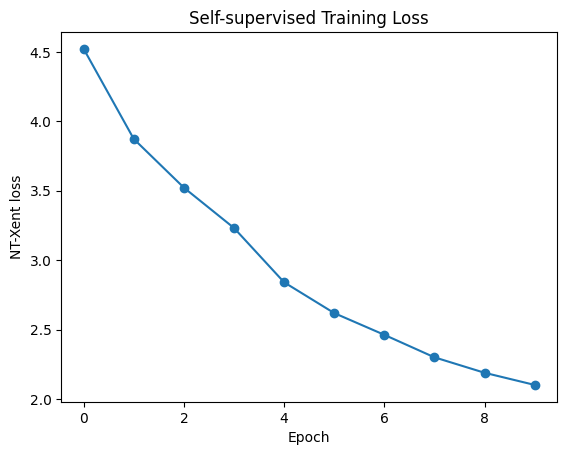

In [ ]:
model.train()
loss_hist = []

for ep in range(1, EPOCHS+1):
    ep_loss = 0.0
    for v1, v2 in train_loader:
        v1 = v1.to(DEVICE)
        v2 = v2.to(DEVICE)

        _, p1 = model(v1)
        _, p2 = model(v2)

        loss = nt_xent_loss(p1, p2, tau=0.2)

        opt.zero_grad()
        loss.backward()
        opt.step()

        ep_loss += loss.item()

    ep_loss /= max(1, len(train_loader))
    loss_hist.append(ep_loss)
    print(f"Epoch {ep:02d} | ssl_loss={ep_loss:.4f}")

plt.figure()
plt.plot(loss_hist, marker="o")
plt.title("Self-supervised Training Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.show()

In [ ]:
# @title
print("Last-6h cycles:", df_6h["global_cycle_id"].nunique())

Last-6h cycles: 10


# Apply the codes form cell 6 from chatgpt - and check question from notes get answered and prepare report

✅ CELL 6 — Extract embeddings for all last-6h events

In [ ]:
class MelSingleDataset(Dataset):
    def __init__(self, df_6h, chunks_dir):
        self.df = df_6h.reset_index(drop=True)
        self.chunks_dir = chunks_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fn = self.df.loc[idx, "filename"]
        wav_path = os.path.join(self.chunks_dir, fn)
        mel = wav_to_logmel(wav_path, sr=SR)
        x = torch.tensor(mel[None, ...], dtype=torch.float32)
        return x, idx

single_ds = MelSingleDataset(df_6h, CHUNKS_DIR)
single_loader = DataLoader(single_ds, batch_size=BATCH, shuffle=False, num_workers=0)

model.eval()
embs = np.zeros((len(df_6h), EMB_DIM), dtype=np.float32)

with torch.no_grad():
    for xb, idxb in single_loader:
        xb = xb.to(DEVICE)
        h, _ = model(xb)
        h = h.detach().cpu().numpy()
        embs[idxb.numpy()] = h

dfE = df_6h.reset_index(drop=True).copy()
for j in range(EMB_DIM):
    dfE[f"e{j}"] = embs[:, j]




print("Event embeddings:", embs.shape)
print("Unique cycles:", dfE["global_cycle_id"].nunique())



Event embeddings: (2871, 128)
Unique cycles: 10


/tmp/ipython-input-866/307534820.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfE[f"e{j}"] = embs[:, j]
/tmp/ipython-input-866/307534820.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfE[f"e{j}"] = embs[:, j]
/tmp/ipython-input-866/307534820.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.c

✅ CELL 7 — Build cycle trajectory vector (12 bins concatenated)

In [ ]:
E_COLS = [f"e{j}" for j in range(EMB_DIM)]

# mean embedding per (cycle, time_bin)
cycle_bin = (
    dfE.groupby(["global_cycle_id", "time_bin"], observed=True)[E_COLS]
    .mean()
    .reset_index()
)

# pivot to wide: one row per cycle, columns for each (bin, emb_dim)
wide = cycle_bin.pivot(index="global_cycle_id", columns="time_bin", values=E_COLS)

# wide columns are multiindex (emb_col, time_bin) OR (time_bin, emb_col) depending on pivot
# normalize to: [bin][emb_dim] then flatten
# We'll rebuild cleanly in order.
cycles = wide.index.tolist()

X_list = []
mask_list = []

for cid in cycles:
    vec = []
    msk = []
    for b in BIN_ORDER:  # far->near order, 12 bins
        if (cid in wide.index) and (b in wide.columns.levels[0] or b in wide.columns.levels[-1]):
            try:
                block = wide.loc[cid, b].values.astype(np.float32)  # shape (emb_dim,)
            except Exception:
                # alternative column order
                block = wide.loc[cid].xs(b, level=1).values.astype(np.float32)

            if block.shape[0] != EMB_DIM:
                block = block.reshape(-1)[:EMB_DIM]
            vec.append(block)
            msk.append(np.ones(EMB_DIM, dtype=np.float32))
        else:
            vec.append(np.full((EMB_DIM,), np.nan, dtype=np.float32))
            msk.append(np.zeros(EMB_DIM, dtype=np.float32))

    X_list.append(np.concatenate(vec))
    mask_list.append(np.concatenate(msk))

X = np.stack(X_list)          # (n_cycles, 12*emb_dim)
M = np.stack(mask_list)       # same shape: 1 where present, 0 where missing

print("Cycle vectors:", X.shape, "Mask:", M.shape)

# keep cycles with >= 6 bins present (at least half)
bins_present = (M.reshape(len(cycles), len(BIN_ORDER), EMB_DIM).mean(axis=2) > 0).sum(axis=1)
keep = bins_present >= 6
X_keep = X[keep]
M_keep = M[keep]
cycles_keep = [c for c, k in zip(cycles, keep) if k]

print("Kept cycles:", len(cycles_keep), "/", len(cycles))

Cycle vectors: (10, 1536) Mask: (10, 1536)
Kept cycles: 10 / 10


✅ CELL 8 — Similarity heatmap + clustering + UMAP (cycle-level)

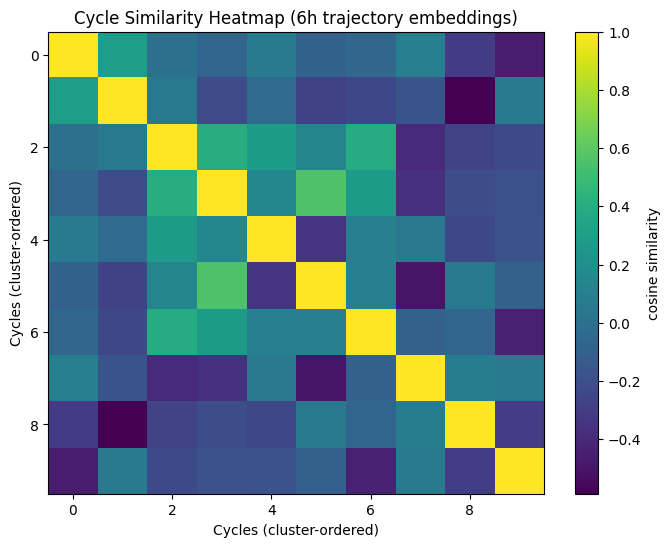

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


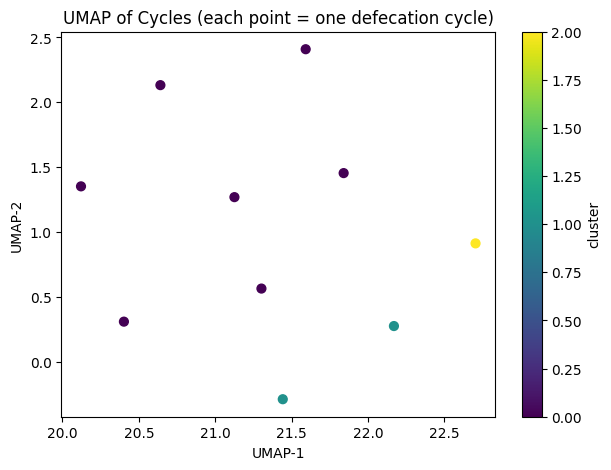

Saved: results_code_set4/cycle_clusters_6h_ssl.csv


,global_cycle_id,cluster
0,10_0,0
1,11_0,0
2,2_0,0
3,2_1,2
4,3_0,0


In [ ]:
# Impute NaNs (only for clustering/UMAP), using column means
imp = SimpleImputer(strategy="mean")
X_imp = imp.fit_transform(X_keep)

# Standardize for UMAP/clustering
sc = StandardScaler()
Xz = sc.fit_transform(X_imp)

# Similarity matrix (cosine)
S = cosine_similarity(Xz)

# Agglomerative clustering on distance = 1 - similarity
dist = 1 - S
n_clusters = min(6, max(2, len(cycles_keep)//3))  # safe auto choice
clu = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
labels = clu.fit_predict(dist)

# reorder by cluster for heatmap blocks
order = np.argsort(labels)
S_ord = S[order][:, order]
cycles_ord = [cycles_keep[i] for i in order]
labels_ord = labels[order]

plt.figure(figsize=(8, 6))
plt.imshow(S_ord, aspect="auto")
plt.title("Cycle Similarity Heatmap (6h trajectory embeddings)")
plt.xlabel("Cycles (cluster-ordered)")
plt.ylabel("Cycles (cluster-ordered)")
plt.colorbar(label="cosine similarity")
plt.show()

# UMAP
u = umap.UMAP(n_neighbors=10, min_dist=0.2, random_state=42)
Z = u.fit_transform(Xz)

plt.figure(figsize=(7, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=40)
plt.title("UMAP of Cycles (each point = one defecation cycle)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="cluster")
plt.show()

# Save cycle cluster table
out = pd.DataFrame({"global_cycle_id": cycles_keep, "cluster": labels})
out.to_csv("results_code_set4/cycle_clusters_6h_ssl.csv", index=False)
print("Saved: results_code_set4/cycle_clusters_6h_ssl.csv")
out.head()

In [ ]:
# ===== RUN 1: save clusters =====
out_run1 = out[["global_cycle_id", "cluster"]].copy()
out_run1.to_csv("results_code_set4/cycle_clusters_6h_ssl_run1.csv", index=False)
print("Saved RUN1 clusters:", out_run1.shape)
out_run1.head()

Saved RUN1 clusters: (10, 2)


,global_cycle_id,cluster
0,10_0,0
1,11_0,0
2,2_0,0
3,2_1,2
4,3_0,0


✅ CELL 9 — “What changed inside a cycle?” plot (trajectory view)

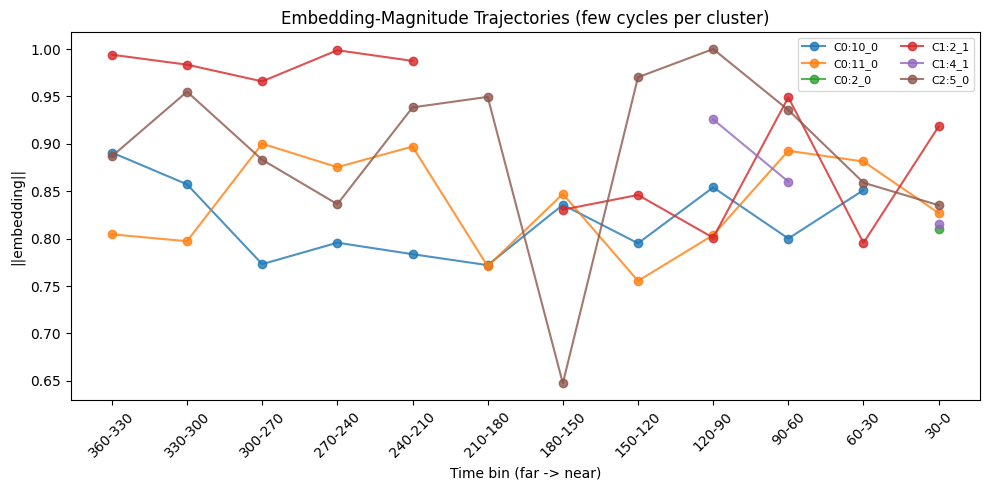

In [ ]:
# embedding magnitude per bin: ||mean embedding||
df_mag = []
for cid in cycles_keep:
    sub = dfE[dfE["global_cycle_id"] == cid]
    if sub.empty:
        continue
    mag = sub.groupby("time_bin", observed=True)[E_COLS].mean().reindex(BIN_ORDER)
    mags = np.linalg.norm(mag.values, axis=1)
    df_mag.append(pd.DataFrame({"global_cycle_id": cid, "time_bin": BIN_ORDER, "emb_mag": mags}))

df_mag = pd.concat(df_mag, ignore_index=True)

# Plot few cycles per cluster
show_per_cluster = 3
plt.figure(figsize=(10, 5))

for cl in sorted(out["cluster"].unique()):
    cids = out[out["cluster"] == cl]["global_cycle_id"].tolist()[:show_per_cluster]
    for cid in cids:
        g = df_mag[df_mag["global_cycle_id"] == cid]
        plt.plot(g["time_bin"].astype(str), g["emb_mag"].values, marker="o", alpha=0.8, label=f"C{cl}:{cid}")

plt.xticks(rotation=45)
plt.title("Embedding-Magnitude Trajectories (few cycles per cluster)")
plt.xlabel("Time bin (far -> near)")
plt.ylabel("||embedding||")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# **Cluster 2**

✅ CELL 4 — Small CNN encoder + projection head + NT-Xent loss

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        h = self.conv(x).squeeze(-1).squeeze(-1)
        z = self.fc(h)
        z = F.normalize(z, dim=1)
        return z

class SimCLR(nn.Module):
    def __init__(self, emb_dim=128, proj_dim=128):
        super().__init__()
        self.encoder = SmallCNN(emb_dim=emb_dim)
        self.proj = nn.Sequential(
            nn.Linear(emb_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        p = self.proj(h)
        p = F.normalize(p, dim=1)
        return h, p

def nt_xent_loss(z1, z2, tau=0.2):
    # z1,z2: (B,D)
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # (2B,D)
    sim = torch.matmul(z, z.T) / tau
    sim.fill_diagonal_(-1e9)

    # positive pairs: i <-> i+B
    targets = torch.arange(0, 2*B, device=z.device)
    targets = (targets + B) % (2*B)

    loss = F.cross_entropy(sim, targets)
    return loss

model = SimCLR(emb_dim=EMB_DIM, proj_dim=EMB_DIM).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR)

FIX 1: Add this helper (pads/crops mel to fixed frames)

In [ ]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# --- FIX: make mel spectrogram fixed-width so DataLoader can stack ---
FIXED_FRAMES = 256   # try 256; if too big/small we can change

def pad_or_crop_mel(mel, T=FIXED_FRAMES):
    # mel: (n_mels, time)
    n_mels, t = mel.shape
    if t == T:
        return mel
    if t > T:
        # crop (take last part OR center). last part is often closer to event end.
        return mel[:, -T:]
    # pad
    pad = np.zeros((n_mels, T - t), dtype=mel.dtype)
    return np.concatenate([mel, pad], axis=1)

✅ CELL 5 — Train self-supervised encoder

In [ ]:
def __getitem__(self, idx):
    fn = self.df.loc[idx, "filename"]
    wav_path = os.path.join(self.chunks_dir, fn)

    mel = wav_to_logmel(wav_path, sr=SR)  # now fixed shape
    if len(x) < N_FFT:
      # pad short signals so STFT is valid
      x = np.pad(x, (0, N_FFT - len(x)), mode="constant")
    v1 = spec_augment(mel)
    v2 = spec_augment(mel)

    v1 = torch.tensor(v1[None, ...], dtype=torch.float32)
    v2 = torch.tensor(v2[None, ...], dtype=torch.float32)
    return v1, v2

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=320
  warnings.warn(


Epoch 01 | ssl_loss=4.3447
Epoch 02 | ssl_loss=3.7463
Epoch 03 | ssl_loss=3.5402
Epoch 04 | ssl_loss=3.2820
Epoch 05 | ssl_loss=3.0397
Epoch 06 | ssl_loss=2.9126
Epoch 07 | ssl_loss=2.6671
Epoch 08 | ssl_loss=2.5198
Epoch 09 | ssl_loss=2.2512
Epoch 10 | ssl_loss=2.1000


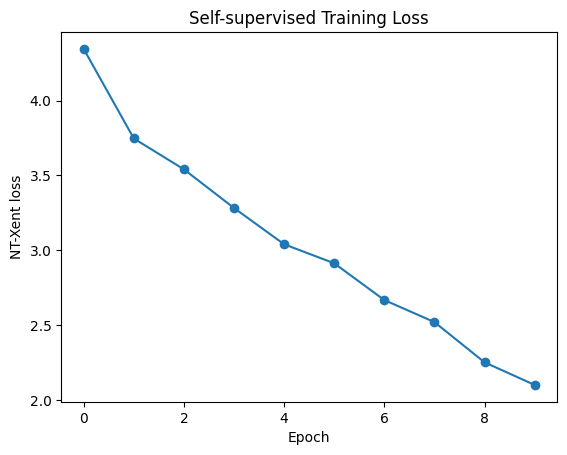

In [ ]:
model.train()
loss_hist = []

for ep in range(1, EPOCHS+1):
    ep_loss = 0.0
    for v1, v2 in train_loader:
        v1 = v1.to(DEVICE)
        v2 = v2.to(DEVICE)

        _, p1 = model(v1)
        _, p2 = model(v2)

        loss = nt_xent_loss(p1, p2, tau=0.2)

        opt.zero_grad()
        loss.backward()
        opt.step()

        ep_loss += loss.item()

    ep_loss /= max(1, len(train_loader))
    loss_hist.append(ep_loss)
    print(f"Epoch {ep:02d} | ssl_loss={ep_loss:.4f}")

plt.figure()
plt.plot(loss_hist, marker="o")
plt.title("Self-supervised Training Loss")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.show()

In [ ]:
print("Last-6h cycles:", df_6h["global_cycle_id"].nunique())

Last-6h cycles: 10


✅ CELL 6 — Extract embeddings for all last-6h events

In [ ]:
class MelSingleDataset(Dataset):
    def __init__(self, df_6h, chunks_dir):
        self.df = df_6h.reset_index(drop=True)
        self.chunks_dir = chunks_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fn = self.df.loc[idx, "filename"]
        wav_path = os.path.join(self.chunks_dir, fn)
        mel = wav_to_logmel(wav_path, sr=SR)
        x = torch.tensor(mel[None, ...], dtype=torch.float32)
        return x, idx

single_ds = MelSingleDataset(df_6h, CHUNKS_DIR)
single_loader = DataLoader(single_ds, batch_size=BATCH, shuffle=False, num_workers=0)

model.eval()
embs = np.zeros((len(df_6h), EMB_DIM), dtype=np.float32)

with torch.no_grad():
    for xb, idxb in single_loader:
        xb = xb.to(DEVICE)
        h, _ = model(xb)
        h = h.detach().cpu().numpy()
        embs[idxb.numpy()] = h


        # TO AVOID THE FRAGMENTATION WARNING

dfE = df_6h.reset_index(drop=True).copy()
E = pd.DataFrame(embs, columns=[f"e{j}" for j in range(embs.shape[1])])
dfE = pd.concat([dfE, E], axis=1)



print("Event embeddings:", embs.shape)
print("Unique cycles:", dfE["global_cycle_id"].nunique())



Event embeddings: (2871, 128)
Unique cycles: 10


✅ CELL 7 — Build cycle trajectory vector (12 bins concatenated)

In [ ]:
E_COLS = [f"e{j}" for j in range(EMB_DIM)]

# mean embedding per (cycle, time_bin)
cycle_bin = (
    dfE.groupby(["global_cycle_id", "time_bin"], observed=True)[E_COLS]
    .mean()
    .reset_index()
)

# pivot to wide: one row per cycle, columns for each (bin, emb_dim)
wide = cycle_bin.pivot(index="global_cycle_id", columns="time_bin", values=E_COLS)

# wide columns are multiindex (emb_col, time_bin) OR (time_bin, emb_col) depending on pivot
# normalize to: [bin][emb_dim] then flatten
# We'll rebuild cleanly in order.
cycles = wide.index.tolist()

X_list = []
mask_list = []

for cid in cycles:
    vec = []
    msk = []
    for b in BIN_ORDER:  # far->near order, 12 bins
        if (cid in wide.index) and (b in wide.columns.levels[0] or b in wide.columns.levels[-1]):
            try:
                block = wide.loc[cid, b].values.astype(np.float32)  # shape (emb_dim,)
            except Exception:
                # alternative column order
                block = wide.loc[cid].xs(b, level=1).values.astype(np.float32)

            if block.shape[0] != EMB_DIM:
                block = block.reshape(-1)[:EMB_DIM]
            vec.append(block)
            msk.append(np.ones(EMB_DIM, dtype=np.float32))
        else:
            vec.append(np.full((EMB_DIM,), np.nan, dtype=np.float32))
            msk.append(np.zeros(EMB_DIM, dtype=np.float32))

    X_list.append(np.concatenate(vec))
    mask_list.append(np.concatenate(msk))

X = np.stack(X_list)          # (n_cycles, 12*emb_dim)
M = np.stack(mask_list)       # same shape: 1 where present, 0 where missing

print("Cycle vectors:", X.shape, "Mask:", M.shape)

# keep cycles with >= 6 bins present (at least half)
bins_present = (M.reshape(len(cycles), len(BIN_ORDER), EMB_DIM).mean(axis=2) > 0).sum(axis=1)
keep = bins_present >= 6
X_keep = X[keep]
M_keep = M[keep]
cycles_keep = [c for c, k in zip(cycles, keep) if k]

print("Kept cycles:", len(cycles_keep), "/", len(cycles))

Cycle vectors: (10, 1536) Mask: (10, 1536)
Kept cycles: 10 / 10


✅ CELL 8 — Similarity heatmap + clustering + UMAP (cycle-level)

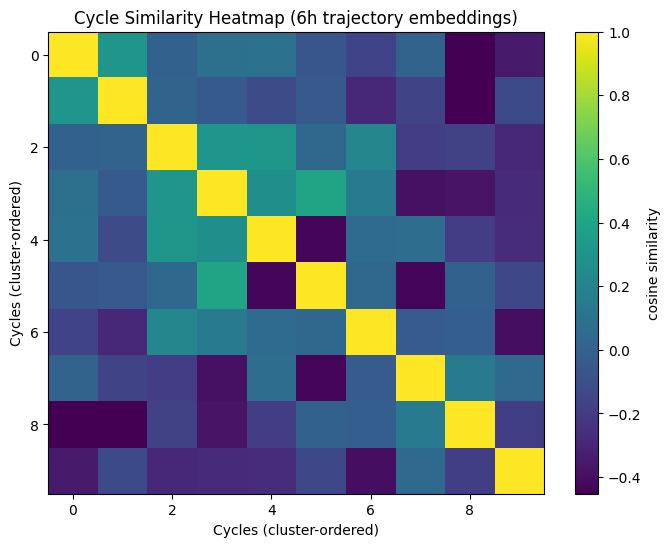

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


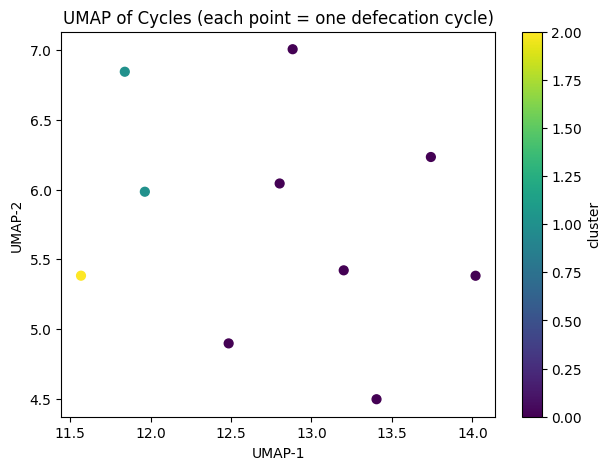

Saved: results_code_set4/cycle_clusters_6h_ssl.csv


,global_cycle_id,cluster
0,10_0,0
1,11_0,0
2,2_0,0
3,2_1,2
4,3_0,0


In [ ]:
# Impute NaNs (only for clustering/UMAP), using column means
imp = SimpleImputer(strategy="mean")
X_imp = imp.fit_transform(X_keep)

# Standardize for UMAP/clustering
sc = StandardScaler()
Xz = sc.fit_transform(X_imp)

# Similarity matrix (cosine)
S = cosine_similarity(Xz)

# Agglomerative clustering on distance = 1 - similarity
dist = 1 - S
n_clusters = min(6, max(2, len(cycles_keep)//3))  # safe auto choice
clu = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
labels = clu.fit_predict(dist)

# reorder by cluster for heatmap blocks
order = np.argsort(labels)
S_ord = S[order][:, order]
cycles_ord = [cycles_keep[i] for i in order]
labels_ord = labels[order]

plt.figure(figsize=(8, 6))
plt.imshow(S_ord, aspect="auto")
plt.title("Cycle Similarity Heatmap (6h trajectory embeddings)")
plt.xlabel("Cycles (cluster-ordered)")
plt.ylabel("Cycles (cluster-ordered)")
plt.colorbar(label="cosine similarity")
plt.show()

# UMAP
u = umap.UMAP(n_neighbors=10, min_dist=0.2, random_state=42)
Z = u.fit_transform(Xz)

plt.figure(figsize=(7, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=40)
plt.title("UMAP of Cycles (each point = one defecation cycle)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="cluster")
plt.show()

# Save cycle cluster table
out = pd.DataFrame({"global_cycle_id": cycles_keep, "cluster": labels})
out.to_csv("results_code_set4/cycle_clusters_6h_ssl.csv", index=False)
print("Saved: results_code_set4/cycle_clusters_6h_ssl.csv")
out.head()

In [ ]:
# ===== RUN 2: save clusters =====
out_run2 = out[["global_cycle_id", "cluster"]].copy()
out_run2.to_csv("results_code_set4/cycle_clusters_6h_ssl_run2.csv", index=False)
print("Saved RUN2 clusters:", out_run2.shape)
out_run2.head()

Saved RUN2 clusters: (10, 2)


,global_cycle_id,cluster
0,10_0,0
1,11_0,0
2,2_0,0
3,2_1,2
4,3_0,0


In [ ]:
print(embs[0, :5])

[-0.07350504  0.05068349 -0.01706117  0.11127167  0.14499198]


In [ ]:
out_run1 = out[["global_cycle_id","cluster"]].copy()
out_run1.to_csv("results_code_set4/cycle_clusters_6h_ssl_run1.csv", index=False)

In [ ]:
out_run2 = out[["global_cycle_id","cluster"]].copy()
out_run2.to_csv("results_code_set4/cycle_clusters_6h_ssl_run2.csv", index=False)

In [ ]:
from sklearn.metrics import adjusted_rand_score

m = out_run1.merge(out_run2, on="global_cycle_id", suffixes=("_r1","_r2"))
ari = adjusted_rand_score(m["cluster_r1"], m["cluster_r2"])
print("Cluster stability (ARI):", ari)
print("Compared cycles:", len(m))

Cluster stability (ARI): 1.0
Compared cycles: 10


🎯 2️⃣ Are patterns stable across re-training?

In [ ]:
from sklearn.metrics import adjusted_rand_score

m = out_run1.merge(out_run2, on="global_cycle_id", suffixes=("_r1","_r2"))

ari = adjusted_rand_score(m["cluster_r1"], m["cluster_r2"])
print("Cluster stability (ARI):", ari)

Cluster stability (ARI): 1.0


🎯 1️⃣ Do clusters correspond to physiological differences?
What this means

If cluster A cycles have:

Higher centroid increase

Higher rolloff

Stronger envelope

Shorter duration

Then clusters reflect different acoustic mechanisms.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Features
emb_cols = [c for c in dfE.columns if c.startswith("e")]
X = dfE[emb_cols].values

# Label: near event (<= 60 min)
y = (dfE["minutes_until_defecation"] <= 60).astype(int).values

# Group by cycle
groups = dfE["global_cycle_id"].values

gkf = GroupKFold(n_splits=5)
aucs = []

for train_idx, test_idx in gkf.split(X, y, groups):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X[train_idx], y[train_idx])
    probs = clf.predict_proba(X[test_idx])[:,1]
    auc = roc_auc_score(y[test_idx], probs)
    aucs.append(auc)

print("Group-wise AUCs:", aucs)
print("Mean Group AUC:", np.mean(aucs))

Group-wise AUCs: [np.float64(0.40595121079438834), np.float64(0.5174937343358397), np.float64(0.6199336128581412), np.float64(0.5750611754928666), np.float64(0.5356270358306189)]
Mean Group AUC: 0.5308133538623709


Add 2 baselines (so we know if 0.53 is meaningful)
Baseline A: “Predict using ONLY time bin frequency” (dumb baseline)

Example: just predict “near” if the dataset has many near points.

Baseline B: “Shuffle labels within each cycle”

If AUC stays similar even after shuffling → your model is not learning real structure.

Here’s the code (drop-in cell):

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# --- Embeddings ---
emb_cols = [c for c in dfE.columns if c.startswith("e")]
X = dfE[emb_cols].values
y = (dfE["minutes_until_defecation"] <= 60).astype(int).values
groups = dfE["global_cycle_id"].values

def groupkfold_auc(X, y, groups, seed=0):
    gkf = GroupKFold(n_splits=5)
    aucs = []
    for tr, te in gkf.split(X, y, groups):
        clf = LogisticRegression(max_iter=2000)
        clf.fit(X[tr], y[tr])
        p = clf.predict_proba(X[te])[:,1]
        aucs.append(roc_auc_score(y[te], p))
    return aucs, float(np.mean(aucs))

# 1) Real AUC
aucs_real, mean_real = groupkfold_auc(X, y, groups)
print("REAL fold AUCs:", aucs_real, "Mean:", mean_real)

# 2) Shuffle labels within each cycle (destroys real link but keeps cycle structure)
rng = np.random.default_rng(0)
y_shuf = y.copy()
for cid in np.unique(groups):
    idx = np.where(groups == cid)[0]
    y_shuf[idx] = rng.permutation(y_shuf[idx])

aucs_shuf, mean_shuf = groupkfold_auc(X, y_shuf, groups)
print("SHUFFLE-IN-CYCLE fold AUCs:", aucs_shuf, "Mean:", mean_shuf)

REAL fold AUCs: [np.float64(0.40595121079438834), np.float64(0.5174937343358397), np.float64(0.6199336128581412), np.float64(0.5750611754928666), np.float64(0.5356270358306189)] Mean: 0.5308133538623709
SHUFFLE-IN-CYCLE fold AUCs: [np.float64(0.5331665326303875), np.float64(0.4851629072681704), np.float64(0.5149589447938504), np.float64(0.505332656170645), np.float64(0.4417752442996743)] Mean: 0.4960792570325456
